## Genome-wide over-methylated nucleosome analysis — chrII

## 1. Imports and setup

In [1]:
import numpy as np
import sys
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tqdm import tqdm
from scipy.signal import find_peaks
import json
from pathlib import Path

parent_path = Path.cwd().parent
if str(parent_path) not in sys.path:
    sys.path.insert(0, str(parent_path))

from nuctool.Plotter import Plotter
plot = Plotter()
print("Imports done")

FIG_SIZE = (15, 4)  # standard figure size: width fixed, height may vary for imshow/tall panels


Imports done


## 2. Model architecture

`DyadPredictor` is a dilated CNN → BiLSTM → FC model that takes an 0–7 encoded sequence (A/C/G/T + methylated counterparts) and outputs a per-position probability of the nucleosome dyad.

`call_dyad_positions` picks peaks from the probability track with a minimum spacing of one nucleosome footprint (147 bp).

In [2]:
class DyadPredictor(nn.Module):
    def __init__(self, vocab_size=8, embedding_dim=16, hidden_dim=64, num_layers=2,
                 dropout=0.3, conv_layers=2, conv_kernel_size=5, conv_dilations=None):
        super().__init__()
        self.vocab_size  = vocab_size
        self.conv_layers = conv_layers
        self.embedding   = nn.Embedding(vocab_size, embedding_dim)
        if conv_dilations is None:
            conv_dilations = [1] * conv_layers
        for i in range(conv_layers):
            in_ch    = embedding_dim if i == 0 else hidden_dim
            dilation = conv_dilations[i] if i < len(conv_dilations) else 1
            padding  = (conv_kernel_size - 1) * dilation // 2
            setattr(self, f"conv{i+1}", nn.Conv1d(in_ch, hidden_dim,
                kernel_size=conv_kernel_size, padding=padding, dilation=dilation))
            setattr(self, f"bn{i+1}", nn.BatchNorm1d(hidden_dim))
        self.lstm = nn.LSTM(hidden_dim, hidden_dim // 2, num_layers=num_layers,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(hidden_dim // 2, 1))

    def forward(self, x):
        x = self.embedding(x).transpose(1, 2)
        for i in range(self.conv_layers):
            x = torch.relu(getattr(self, f"bn{i+1}")(getattr(self, f"conv{i+1}")(x)))
        x, _ = self.lstm(x.transpose(1, 2))
        return self.fc(x)


FOOTPRINT = 147

def call_dyad_positions(probs, min_spacing=FOOTPRINT, min_height=0.0,
                        min_relative_height=0.5, window=100, genomic_start=0):
    if probs.ndim == 1:
        peak_idx, _ = find_peaks(probs, distance=min_spacing, height=min_height)
        if len(peak_idx) == 0:
            return np.array([], dtype=int), np.array([])
        peak_probs  = probs[peak_idx]
        kept_idx, kept_scores = [], []
        for i, idx in enumerate(peak_idx):
            nearby = np.abs(peak_idx - idx) <= window
            total  = peak_probs[nearby].sum()
            score  = peak_probs[i] / total if total > 0 else 0.0
            if score >= min_relative_height:
                kept_idx.append(idx)
                kept_scores.append(score)
        return np.array(kept_idx, dtype=int) + genomic_start, np.array(kept_scores)
    return [call_dyad_positions(row, min_spacing, min_height,
                                min_relative_height, window, genomic_start)
            for row in probs]

## 3. Configuration

Key parameters:
| Parameter | Value | Meaning |
|---|---|---|
| `core_half` | 73 bp | Half-width of nucleosome core used to compute methylation fraction |
| `window_half` | 150 bp | Half-width of sequence window stored per dyad for plotting |
| `min_at_covered` | 80 | Minimum covered A/T positions in core — filters edge-clipped reads |
| `max_methylation` | 18 % | Discard reads with higher overall methylation (likely artifacts) |
| `batch_size` | 32 | Reads processed per GPU batch |

In [3]:
model_filename  = "data/LLM models/LLM_tests/test_2_15000_fitted_variables.pt"
chrom           = "chrII"
data_dir        = Path("../nuctool/full_methylation_data_10000bp_interval") / chrom
device          = torch.device("cuda" if torch.cuda.is_available() else "cpu")

core_half       = 73    # ±73 bp nucleosome core for methylation ranking
window_half     = 150   # bp stored around each dyad for plotting
min_at_covered  = 80    # minimum covered A/T positions in core
max_methylation = 0.18  # discard reads above this methylation fraction
locus_length    = 10000
batch_size      = 32    # reads per GPU batch

encoded_files = sorted(data_dir.glob("encoded_*.npy"))
print(f"Device : {device}")
print(f"Loci   : {len(encoded_files)}")

Device : cuda
Loci   : 82


## 4. Load model

In [4]:
config_path = Path(model_filename).with_suffix(".json")
with open(config_path) as f:
    config = json.load(f)
llm_cfg = config.get("llm", {})

model_params = {
    "vocab_size":       llm_cfg.get("vocab_size", 8),
    "embedding_dim":    llm_cfg.get("embedding_dim", 16),
    "hidden_dim":       llm_cfg.get("hidden_dim", 64),
    "num_layers":       llm_cfg.get("num_layers", 2),
    "dropout":          llm_cfg.get("dropout", 0.3),
    "conv_layers":      llm_cfg.get("conv_layers", 2),
    "conv_kernel_size": llm_cfg.get("conv_kernel_size", 5),
    "conv_dilations":   llm_cfg.get("conv_dilations", None),
}

loaded_model = DyadPredictor(**model_params)
loaded_model.load_state_dict(torch.load(model_filename, map_location=device))
loaded_model = loaded_model.to(device).eval()
print(f"Loaded {model_filename}  ({sum(p.numel() for p in loaded_model.parameters()):,} params)")

Loaded data/LLM models/LLM_tests/test_2_15000_fitted_variables.pt  (680,833 params)


## 5. Run inference across all chrII loci

Loops over all 83 chrII loci (~10 000 bp each). For every locus:
1. Load encoded reads + coverage arrays
2. Filter reads with > 18 % overall methylation
3. Run batched GPU inference → per-position dyad probability
4. Call dyad positions (peaks ≥ 0.2, spaced ≥ 147 bp apart)
5. For each called dyad compute the core (±73 bp) A/T methylation fraction
6. Store the ±150 bp sequence window if the dyad passes the `min_at_covered` filter

All passing dyad records are accumulated in `all_dyad_records`.
**Expected runtime: ~25–35 min on GPU.**

In [5]:
# Loop over all chrII loci — batched GPU inference for speed (~25-35 min on GPU)
all_dyad_records = []   # (genomic_label, frac, n_at, enc_window, cov_window)
n_pos = 2 * window_half + 1

for enc_path in tqdm(encoded_files, desc=f"Processing {chrom}"):
    parts       = enc_path.stem.split('_')            # encoded_START_END
    locus_start = int(parts[1])
    cov_path    = enc_path.parent / f"coverage_{parts[1]}_{parts[2]}.npy"
    if not cov_path.exists():
        continue

    encoded_array  = np.load(enc_path)
    coverage_array = np.load(cov_path).astype(bool)
    actual_len     = encoded_array.shape[1]   # may differ from locus_length at chromosome ends

    # Filter reads with too-high overall methylation
    read_lengths  = coverage_array.sum(axis=1).clip(min=1)
    meth_frac_all = ((encoded_array > 3) & coverage_array).sum(axis=1) / read_lengths
    keep          = meth_frac_all <= max_methylation
    encoded_array  = encoded_array[keep]
    coverage_array = coverage_array[keep]
    if len(encoded_array) == 0:
        continue

    # Clamp to [0, 7] — some files store -1 for uncovered positions, which
    # would crash the CUDA embedding layer; coverage_array already masks those out.
    encoded_array = encoded_array.clip(0, 7)

    # Batched model inference
    n_reads   = len(encoded_array)
    all_probs = np.zeros((n_reads, actual_len), dtype=np.float32)
    with torch.no_grad():
        for b in range(0, n_reads, batch_size):
            batch       = torch.LongTensor(encoded_array[b:b + batch_size]).to(device)
            probs_batch = torch.sigmoid(loaded_model(batch)).squeeze(-1).cpu().numpy()
            all_probs[b:b + batch_size] = probs_batch

    # Call dyad positions
    dyad_results = call_dyad_positions(
        all_probs, min_spacing=FOOTPRINT, min_height=0.2,
        min_relative_height=0.0, window=FOOTPRINT // 2
    )

    # Compute core methylation and store windows for each dyad
    for read_idx, (dyad_pos, _) in enumerate(dyad_results):
        enc = encoded_array[read_idx]
        cov = coverage_array[read_idx]
        for d in dyad_pos:
            lo = max(0, d - core_half)
            hi = min(actual_len, d + core_half + 1)
            at  = np.isin(enc[lo:hi], [0, 3, 4, 7]) & cov[lo:hi]
            mth = (enc[lo:hi] > 3) & at
            n_at = int(at.sum())
            if n_at < min_at_covered:
                continue
            frac = float(mth.sum() / n_at)

            src_lo = max(0, d - window_half)
            src_hi = min(actual_len, d + window_half + 1)
            dst_lo = src_lo - (d - window_half)
            dst_hi = dst_lo + (src_hi - src_lo)
            enc_w  = np.zeros(n_pos, dtype=np.uint8)
            cov_w  = np.zeros(n_pos, dtype=bool)
            enc_w[dst_lo:dst_hi] = enc[src_lo:src_hi]
            cov_w[dst_lo:dst_hi] = cov[src_lo:src_hi]

            all_dyad_records.append((
                f"{chrom}:{locus_start + d}", frac, n_at, enc_w, cov_w
            ))

fracs_all = np.array([r[1] for r in all_dyad_records])
print(f"\nTotal dyads : {len(all_dyad_records)}")
print(f"Core meth   — mean: {fracs_all.mean():.2%}  median: {np.median(fracs_all):.2%}  max: {fracs_all.max():.2%}")

Processing chrII:   0%|          | 0/82 [00:00<?, ?it/s]

Processing chrII: 100%|██████████| 82/82 [03:43<00:00,  2.73s/it]


Total dyads : 1815966
Core meth   — mean: 3.06%  median: 2.33%  max: 21.69%


## 6. Sort and select over-methylated nucleosomes

Sort all collected dyads by core methylation fraction (highest first). The histogram shows the full distribution — the red dashed line marks the cutoff for `n_top`. Adjust `n_top` to inspect more or fewer outliers.

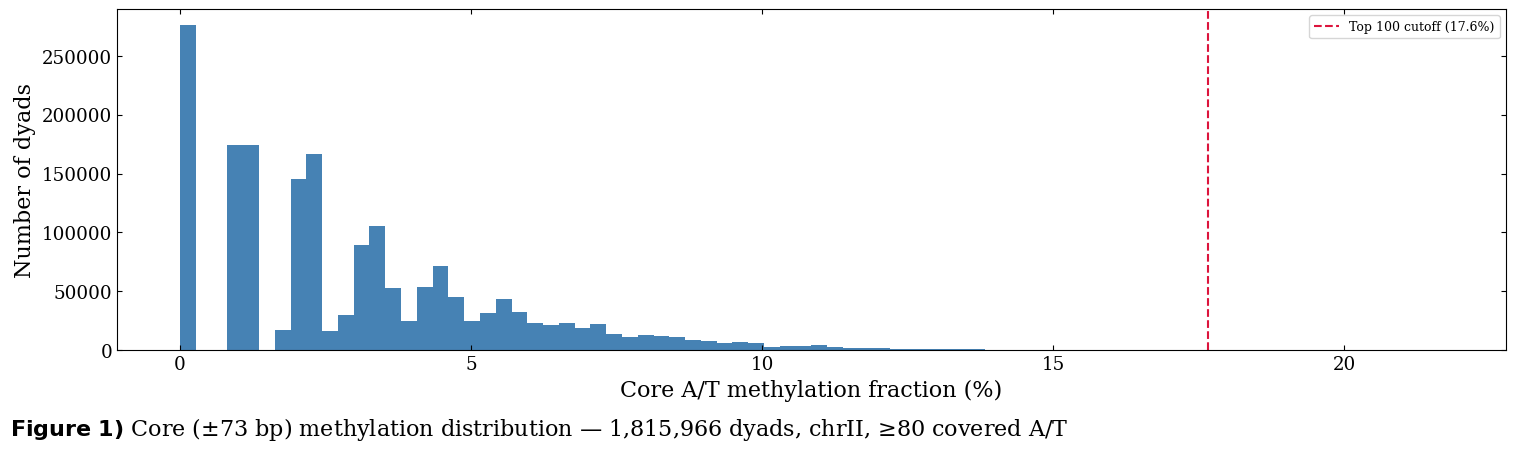

In [6]:
# Sort and select top over-methylated dyads
all_dyad_records.sort(key=lambda x: x[1], reverse=True)
fracs = np.array([r[1] for r in all_dyad_records])

n_top     = 100   # number of most-methylated dyads to inspect
top_group = all_dyad_records[:n_top]

plot.new(fig_size=FIG_SIZE)
plt.hist(fracs * 100, bins=80, color='steelblue', edgecolor='none')
plt.axvline(fracs[n_top - 1] * 100, color='crimson', lw=1.5, ls='--',
            label=f'Top {n_top} cutoff ({fracs[n_top - 1]:.1%})')
plt.xlabel("Core A/T methylation fraction (%)")
plt.ylabel("Number of dyads")
plt.legend(fontsize=9)
plot.caption(
    f"Core (±{core_half} bp) methylation distribution — {len(all_dyad_records):,} dyads, "
    f"{chrom}, ≥{min_at_covered} covered A/T"
)

## 7. Visualise individual reads

Two imshow plots for the top `n_top` over-methylated nucleosomes, each centred on the predicted dyad (position 0):

- **Methylation** — black = methylated A/T, white = unmethylated, light blue = uncovered
- **Sequence** — green = A, blue = C, orange = G, red = T; black dots mark methylated positions

Each row is labelled with genomic coordinate and core methylation fraction.

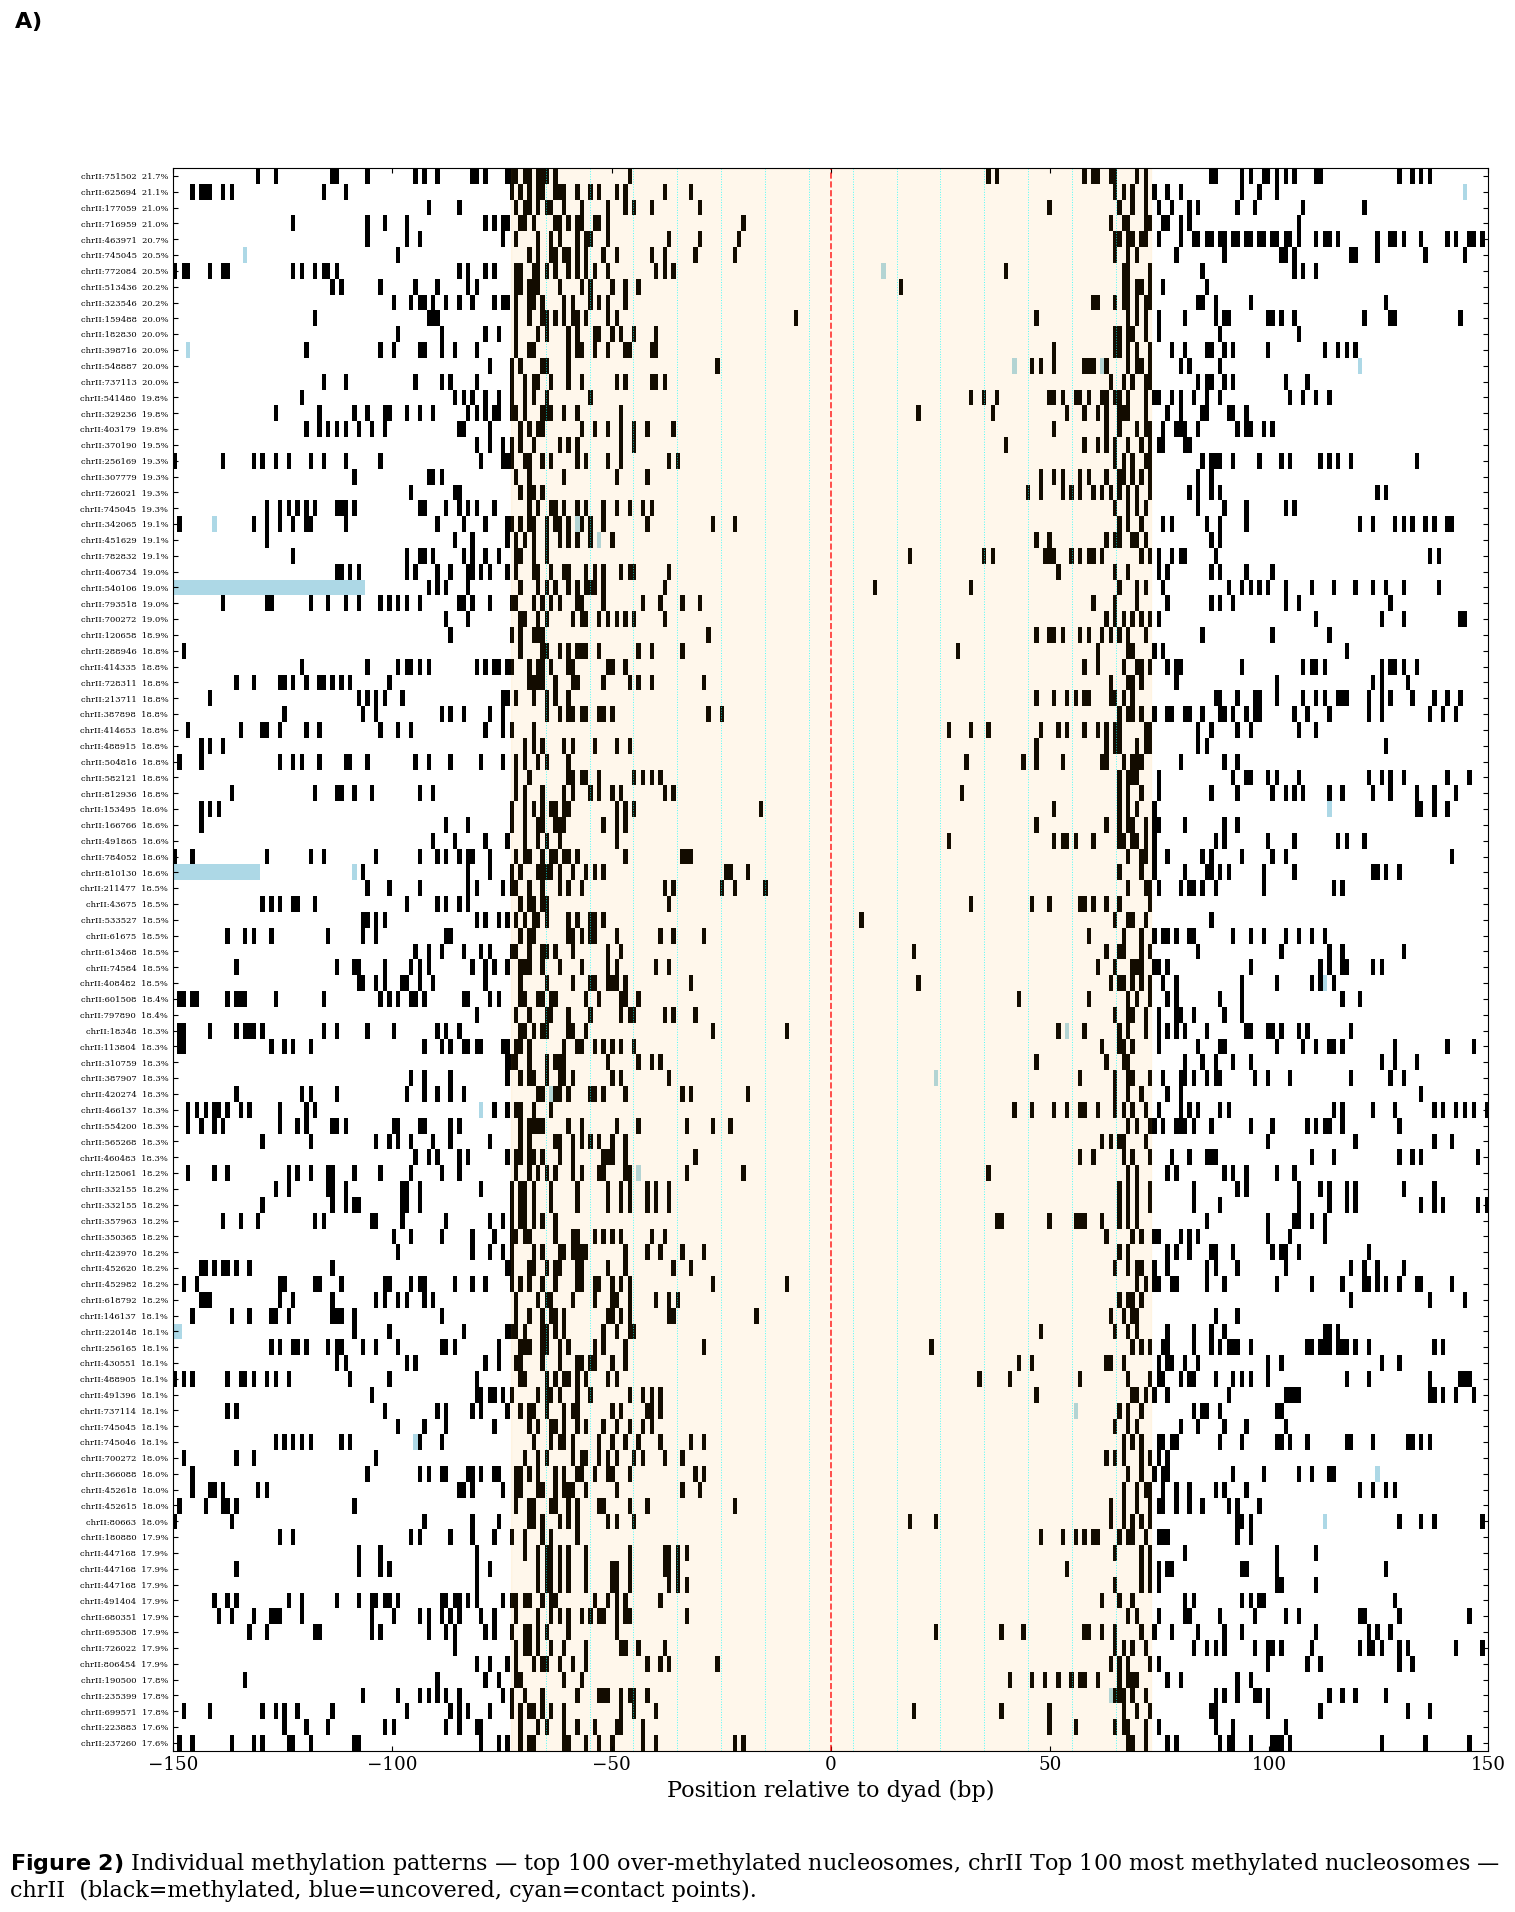

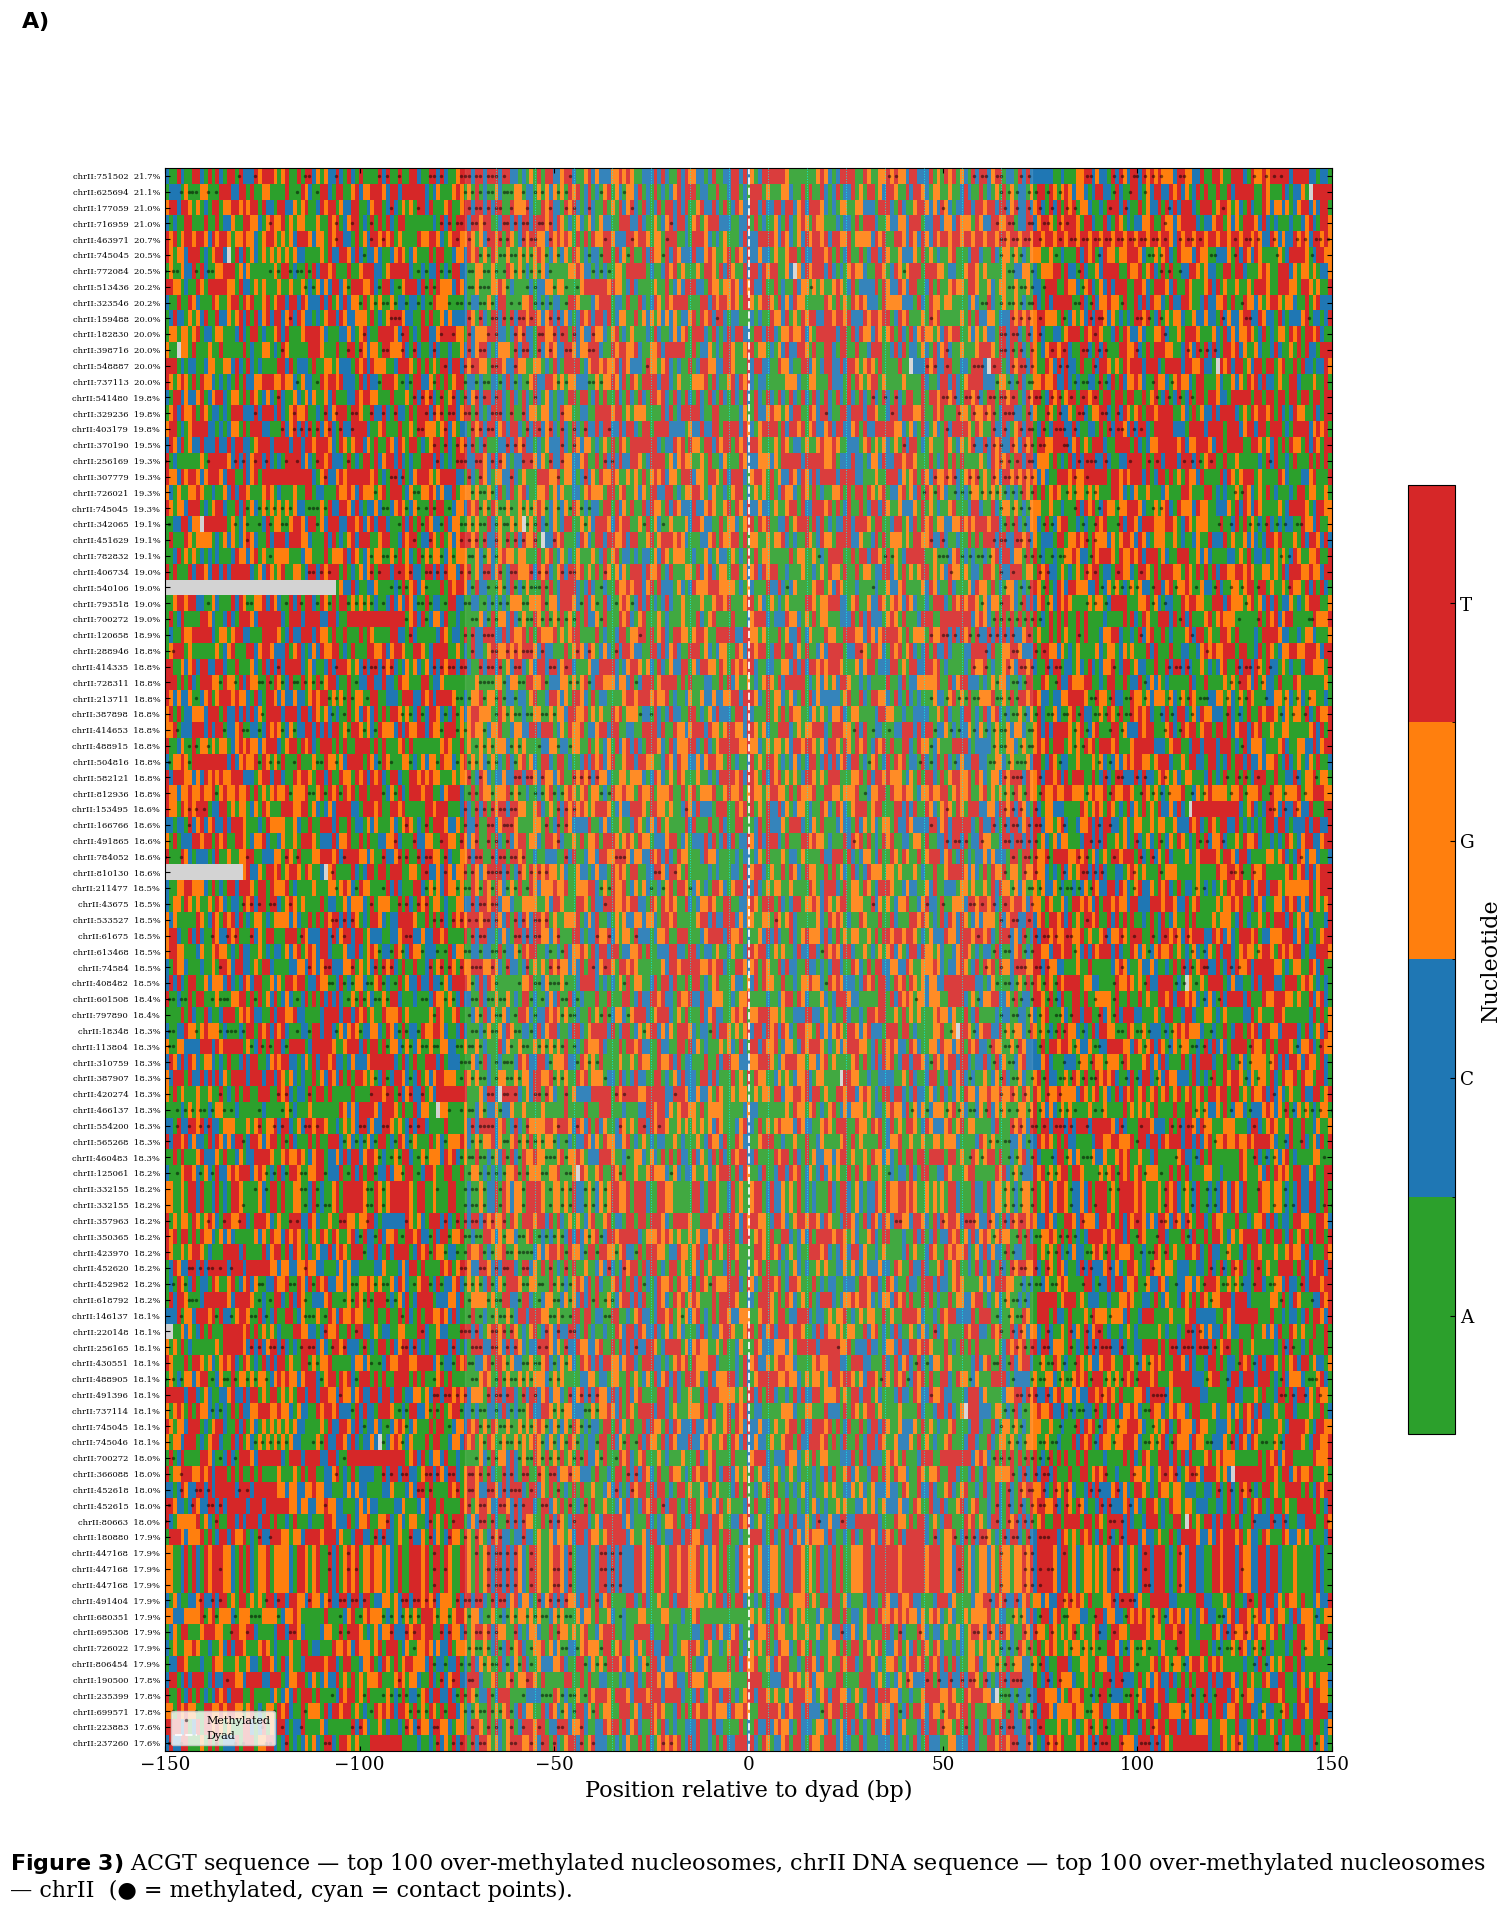

In [7]:
# Nucleosome–histone contact positions: minor groove faces inward at ±5, ±15, ±25 ... ±75 bp
# First contacts are ±5 bp from the dyad, then every 10 bp outward
shl_contacts = [10 * n + 5 for n in range(-7, 7)]

# Methylation imshow — individual reads centred on dyad
n_pos = 2 * window_half + 1
meth_matrix = np.full((n_top, n_pos), np.nan)
for row, (_, frac, _, enc_w, cov_w) in enumerate(top_group):
    meth_matrix[row] = np.where(cov_w, (enc_w > 3).astype(float), np.nan)

cmap_m = plt.get_cmap('Greys').copy()
cmap_m.set_bad('lightblue')

plot.new(fig_size=(FIG_SIZE[0], max(4, n_top * 0.18)))
ax = plt.gca()
ax.imshow(meth_matrix, aspect='auto', cmap=cmap_m, vmin=0, vmax=1,
          interpolation='nearest', extent=[-window_half, window_half, n_top, 0])
ax.axvline(0, color='red', lw=1.2, ls='--', alpha=0.8, label='Dyad')
ax.axvspan(-core_half, core_half, alpha=0.08, color='orange')
for pos in shl_contacts:
    ax.axvline(pos, color='cyan', lw=0.7, ls=':', alpha=0.7)
ax.set_xlabel("Position relative to dyad (bp)")
ax.set_title(f"Top {n_top} most methylated nucleosomes — {chrom}  (black=methylated, blue=uncovered, cyan=contact points)")
ax.set_yticks([r + 0.5 for r in range(n_top)])
ax.set_yticklabels([f"{lk}  {f:.1%}" for lk, f, _, _, _ in top_group], fontsize=6)
plot.caption(f"Individual methylation patterns — top {n_top} over-methylated nucleosomes, {chrom}")

# Sequence imshow (ACGT coloured)
positions   = np.arange(-window_half, window_half + 1)
seq_matrix  = np.full((n_top, n_pos), np.nan)
meth_xs, meth_ys = [], []

for row, (_, frac, _, enc_w, cov_w) in enumerate(top_group):
    seq_matrix[row] = np.where(cov_w, enc_w % 4, np.nan)
    meth_mask = cov_w & (enc_w > 3)
    meth_xs.extend(positions[meth_mask].tolist())
    meth_ys.extend([row + 0.5] * int(meth_mask.sum()))

nuc_cmap = mcolors.ListedColormap(['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'])
nuc_cmap.set_bad('lightgrey')
nuc_norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], ncolors=4)

plot.new(fig_size=(FIG_SIZE[0], max(4, n_top * 0.18)))
ax = plt.gca()
img = ax.imshow(seq_matrix, aspect='auto', cmap=nuc_cmap, norm=nuc_norm,
                interpolation='nearest', extent=[-window_half, window_half, n_top, 0])
if meth_xs:
    ax.scatter(meth_xs, meth_ys, s=6, c='black', marker='o',
               zorder=3, alpha=0.5, linewidths=0, label='Methylated')
ax.axvline(0, color='white', lw=1.4, ls='--', alpha=0.9, label='Dyad')
ax.axvspan(-core_half, core_half, alpha=0.10, color='white')
for pos in shl_contacts:
    ax.axvline(pos, color='cyan', lw=0.7, ls=':', alpha=0.8, zorder=4)
cbar = plt.colorbar(img, ax=ax, ticks=[0, 1, 2, 3], shrink=0.6)
cbar.ax.set_yticklabels(['A', 'C', 'G', 'T'])
cbar.set_label('Nucleotide')
ax.set_xlabel("Position relative to dyad (bp)")
ax.set_title(f"DNA sequence — top {n_top} over-methylated nucleosomes — {chrom}  (● = methylated, cyan = contact points)")
ax.legend(fontsize=8, loc='lower left')
ax.set_yticks([r + 0.5 for r in range(n_top)])
ax.set_yticklabels([f"{lk}  {f:.1%}" for lk, f, _, _, _ in top_group], fontsize=6)
plot.caption(f"ACGT sequence — top {n_top} over-methylated nucleosomes, {chrom}")

## 8. Dinucleotide frequency

Computes the frequency of each dinucleotide group at every position ±150 bp from the dyad across the top `n_top` nucleosomes. Complementary pairs are summed (e.g. AA+TT) since the two strands are equivalent.

The classic nucleosome positioning signal is a ~10 bp periodicity in AA+TT (minor groove compression) and an anti-phase oscillation in GC. With enough dyads this periodicity should be clearly visible.

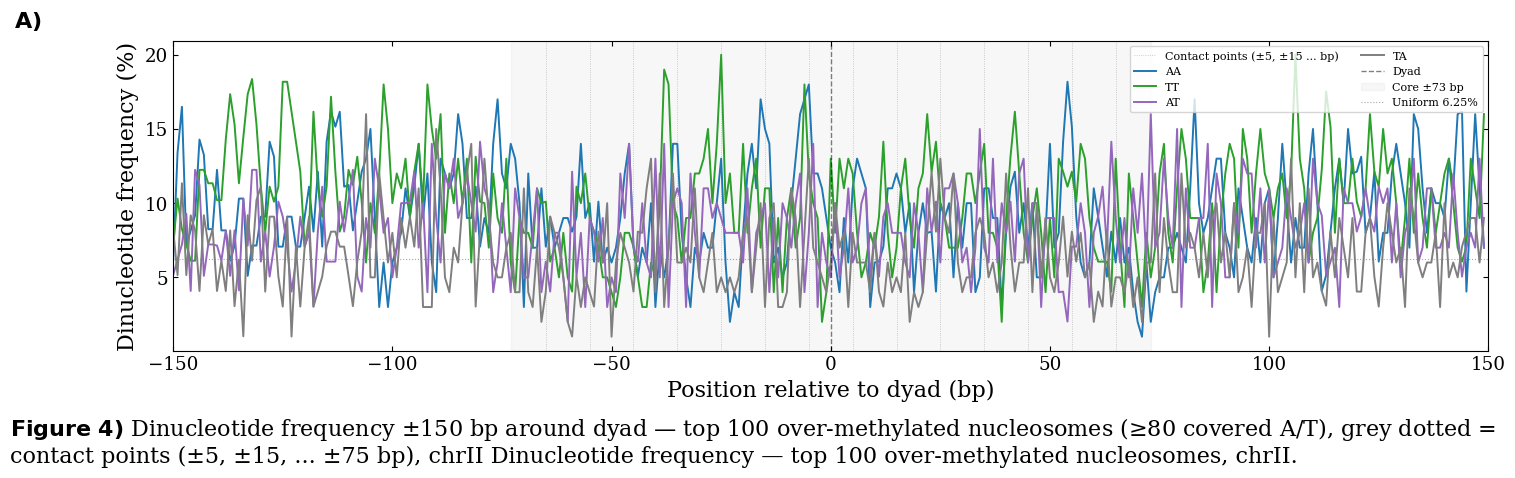

In [8]:
# Dinucleotide frequency line plot — uses seq_matrix from the cell above
dinuc_labels = [b1 + b2 for b1 in 'ACGT' for b2 in 'ACGT']
dinuc_index  = {label: i for i, label in enumerate(dinuc_labels)}

nuc1  = seq_matrix[:, :-1]
nuc2  = seq_matrix[:, 1:]
valid = ~np.isnan(nuc1) & ~np.isnan(nuc2)
dinuc_idx = np.where(valid, (nuc1 * 4 + nuc2).astype(float), np.nan)

n_di_pos      = nuc1.shape[1]
total_per_pos = valid.sum(axis=0).astype(np.float64)

def dinuc_freq_line(label):
    di     = dinuc_index[label]
    counts = (dinuc_idx == di).sum(axis=0).astype(np.float64)
    return np.where(total_per_pos > 0, counts / total_per_pos, np.nan)

to_plot = {
    'AA':       dinuc_freq_line('AA'),
    'TT':       dinuc_freq_line('TT'),
    'AT':      dinuc_freq_line('AT'),
    'TA':      dinuc_freq_line('TA'),
    # 'GC':      dinuc_freq_line('GC'),
    # 'CG':      dinuc_freq_line('CG'),
    # 'AC + GT': dinuc_freq_line('AC') + dinuc_freq_line('GT'),
    # 'TC + GA': dinuc_freq_line('TC') + dinuc_freq_line('GA'),
}

di_positions = np.arange(-window_half, window_half)
colors = plt.cm.tab10(np.linspace(0, 0.7, len(to_plot)))

plot.new(fig_size=FIG_SIZE)
ax = plt.gca()

# Contact lines in background first
for i, pos in enumerate(shl_contacts):
    ax.axvline(pos, color='grey', lw=0.6, ls=':', alpha=0.5,
               label='Contact points (±5, ±15 ... bp)' if i == 0 else None, zorder=0)

for (label, freq), color in zip(to_plot.items(), colors):
    ax.plot(di_positions, freq * 100, lw=1.4, label=label, color=color)

ax.axvline(0, color='k', lw=1, ls='--', alpha=0.5, label='Dyad')
ax.axvspan(-core_half, core_half, alpha=0.06, color='grey', label=f'Core ±{core_half} bp')
ax.axhline(100 / 16, color='grey', lw=0.8, ls=':', alpha=0.7, label='Uniform 6.25%')
ax.set_xlabel("Position relative to dyad (bp)")
ax.set_ylabel("Dinucleotide frequency (%)")
ax.set_xlim(-window_half, window_half)
ax.set_title(f"Dinucleotide frequency — top {n_top} over-methylated nucleosomes, {chrom}")
ax.legend(fontsize=8, ncol=2)
plot.caption(
    f"Dinucleotide frequency ±{window_half} bp around dyad — "
    f"top {n_top} over-methylated nucleosomes (≥{min_at_covered} covered A/T), "
    f"grey dotted = contact points (±5, ±15, ... ±75 bp), {chrom}"
)

## 9. Dinucleotide frequency — all chrII dyads

Same analysis as section 8 but over **all** 1.3 M dyads rather than just the top `n_top`.  
Counts are accumulated in batches to keep memory usage low (~3 MB/batch).

Accumulating dinucleotides: 100%|██████████| 182/182 [00:09<00:00, 19.10it/s]


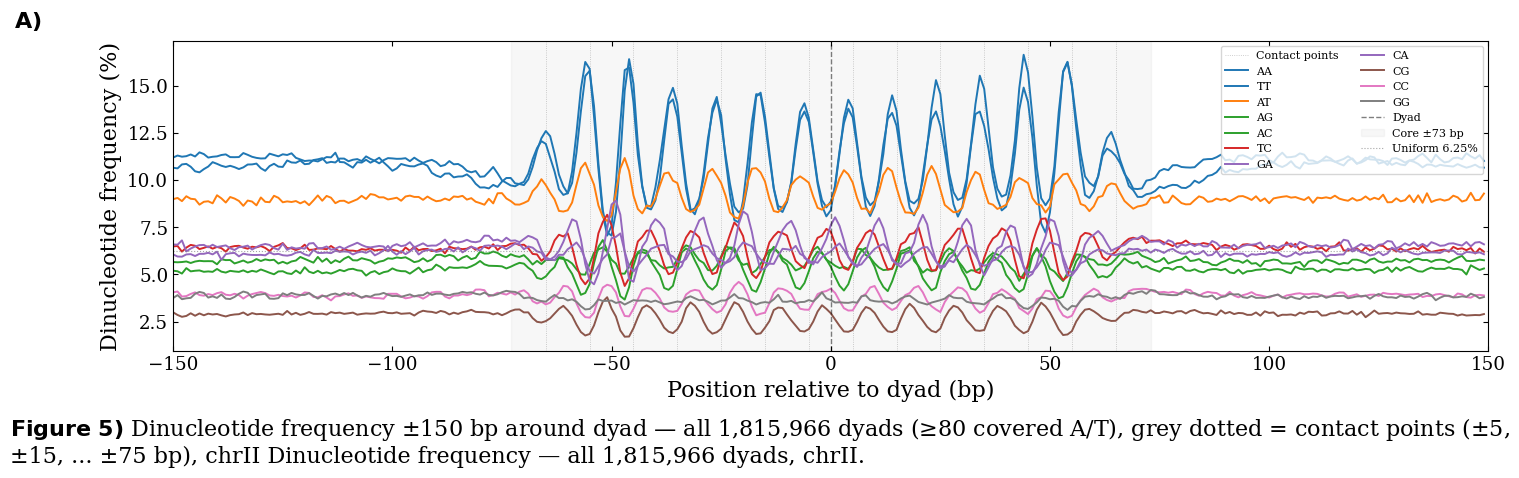

In [9]:
# Accumulate dinucleotide counts over ALL dyads in batches to save memory
n_di_pos         = n_pos - 1
dinuc_counts_all = np.zeros((16, n_di_pos), dtype=np.int64)
total_all        = np.zeros(n_di_pos,       dtype=np.int64)

BATCH = 10_000
for start in tqdm(range(0, len(all_dyad_records), BATCH), desc="Accumulating dinucleotides"):
    batch     = all_dyad_records[start : start + BATCH]
    enc_batch = np.stack([r[3] for r in batch])       # (B, n_pos), uint8
    cov_batch = np.stack([r[4] for r in batch])       # (B, n_pos), bool
    seq       = (enc_batch % 4).astype(np.uint8)      # strip methylation
    valid     = cov_batch[:, :-1] & cov_batch[:, 1:]  # both positions covered
    di        = (seq[:, :-1] * 4 + seq[:, 1:]).astype(np.uint8)  # 0-15
    total_all += valid.sum(axis=0)
    for d in range(16):
        dinuc_counts_all[d] += ((di == d) & valid).sum(axis=0)

dinuc_freq_all = np.where(total_all > 0,
                          dinuc_counts_all / total_all,
                          np.nan)

di_positions = np.arange(-window_half, window_half)
to_plot_all = {
    'AA':       dinuc_freq_all[dinuc_index['AA']],
    'TT':       dinuc_freq_all[dinuc_index['TT']],
    'AT':       dinuc_freq_all[dinuc_index['AT']],
    # 'TA':       dinuc_freq_all[dinuc_index['TA']],
    'AG':       dinuc_freq_all[dinuc_index['AG']],
    'AC':       dinuc_freq_all[dinuc_index['AC']],
    'TC':       dinuc_freq_all[dinuc_index['TC']],
    # 'TG':       dinuc_freq_all[dinuc_index['TG']],
    # 'GC':       dinuc_freq_all[dinuc_index['GC']],
    # 'GT':       dinuc_freq_all[dinuc_index['GT']],
    'GA':       dinuc_freq_all[dinuc_index['GA']],
    # 'CT':       dinuc_freq_all[dinuc_index['CT']],
    'CA':       dinuc_freq_all[dinuc_index['CA']],
    'CG':       dinuc_freq_all[dinuc_index['CG']],
    'CC':       dinuc_freq_all[dinuc_index['CC']],
    'GG':       dinuc_freq_all[dinuc_index['GG']],
}

colors = plt.cm.tab10(np.linspace(0, 0.7, len(to_plot_all)))
plot.new(fig_size=FIG_SIZE)
ax = plt.gca()
for i, pos in enumerate(shl_contacts):
    ax.axvline(pos, color='grey', lw=0.6, ls=':', alpha=0.5,
               label='Contact points' if i == 0 else None, zorder=0)
for (label, freq), color in zip(to_plot_all.items(), colors):
    ax.plot(di_positions, freq * 100, lw=1.4, label=label, color=color)
ax.axvline(0, color='k', lw=1, ls='--', alpha=0.5, label='Dyad')
ax.axvspan(-core_half, core_half, alpha=0.06, color='grey', label=f'Core ±{core_half} bp')
ax.axhline(100 / 16, color='grey', lw=0.8, ls=':', alpha=0.7, label='Uniform 6.25%')
ax.set_xlabel("Position relative to dyad (bp)")
ax.set_ylabel("Dinucleotide frequency (%)")
ax.set_xlim(-window_half, window_half)
ax.set_title(f"Dinucleotide frequency — all {len(all_dyad_records):,} dyads, {chrom}")
ax.legend(fontsize=8, ncol=2, loc='upper right')
plot.caption(
    f"Dinucleotide frequency ±{window_half} bp around dyad — "
    f"all {len(all_dyad_records):,} dyads (≥{min_at_covered} covered A/T), "
    f"grey dotted = contact points (±5, ±15, ... ±75 bp), {chrom}"
)

## 10. Methylation location within nucleosomes

Computes the mean A/T methylation fraction at every position ±150 bp from the dyad, accumulated across all dyads in batches.

- **Protection profile**: nucleosome-wrapped DNA should be methylated less near the dyad; linker regions should show higher methylation. The profile should dip to a minimum at the core (±73 bp) and rise in the flanks.
- **SHL oscillations**: partial unwrapping from each successive contact point (grey dotted lines) may produce oscillations within the core region.
- **Stratification by core methylation quartile**: splitting dyads into quartiles (highest 25 % vs lowest 25 %) tests whether over-methylated nucleosomes lack a protection dip or just have an elevated baseline. Since `all_dyad_records` is already sorted highest-first, quartile slicing is free.

Computing overall methylation profile …
Computing stratified methylation profiles …


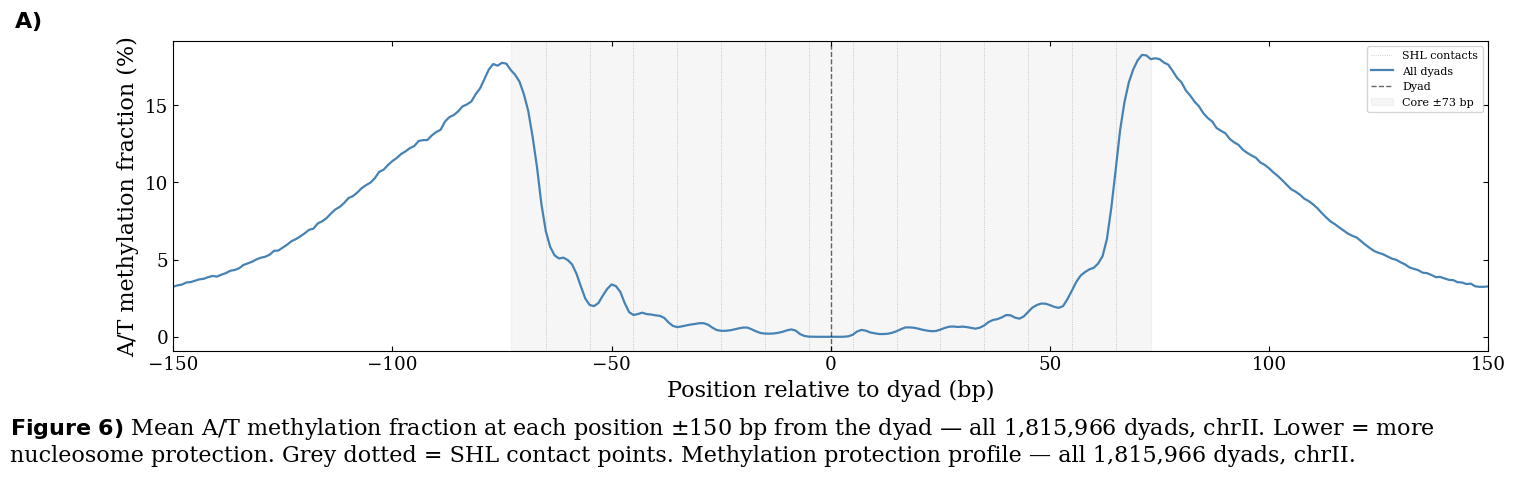

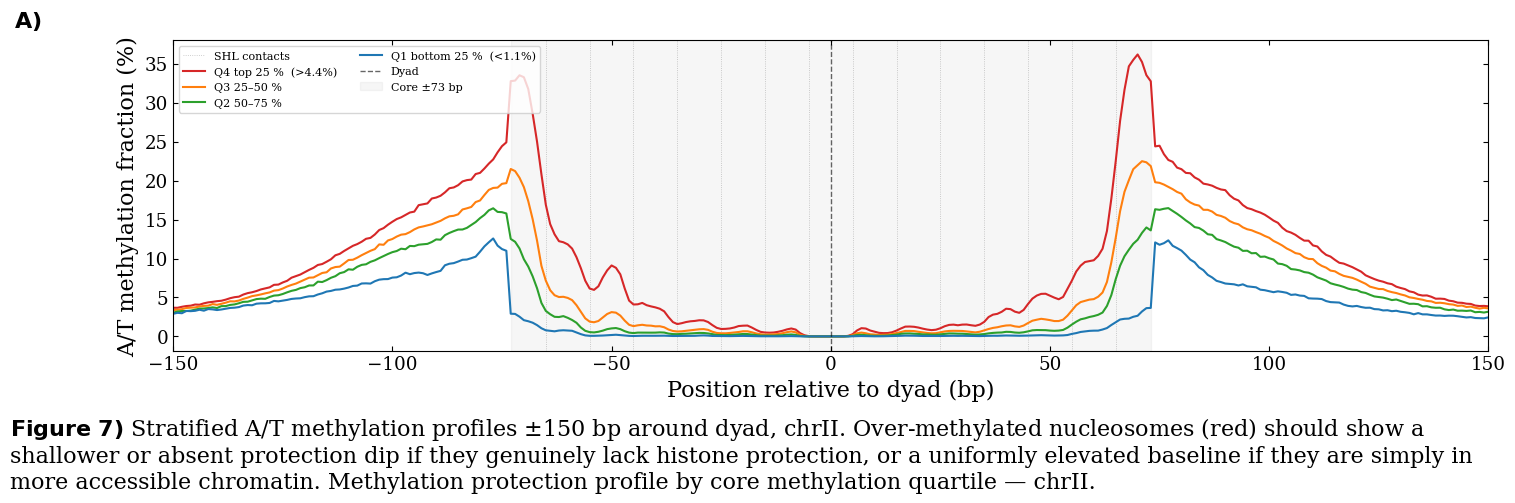

In [10]:
def meth_profile_for_records(records):
    """Return per-position A/T methylation fraction for a list of dyad records."""
    n  = 2 * window_half + 1
    meth_sum = np.zeros(n, dtype=np.float64)
    at_sum   = np.zeros(n, dtype=np.float64)
    BATCH = 10_000
    for s in range(0, len(records), BATCH):
        batch     = records[s : s + BATCH]
        enc_batch = np.stack([r[3] for r in batch])   # (B, n_pos)
        cov_batch = np.stack([r[4] for r in batch])   # (B, n_pos)
        base      = enc_batch % 4                      # 0=A 1=C 2=G 3=T
        is_at     = ((base == 0) | (base == 3)) & cov_batch   # covered A/T
        is_meth   = (enc_batch > 3) & is_at                   # methylated A/T
        meth_sum += is_meth.sum(axis=0).astype(np.float64)
        at_sum   += is_at.sum(axis=0).astype(np.float64)
    return np.where(at_sum > 0, meth_sum / at_sum, np.nan)


# ── Overall methylation profile — all dyads ────────────────────────────────
print("Computing overall methylation profile …")
profile_all = meth_profile_for_records(all_dyad_records)
pos = np.arange(-window_half, window_half + 1)

plot.new(fig_size=FIG_SIZE)
ax = plt.gca()
for i, c in enumerate(shl_contacts):
    ax.axvline(c, color='grey', lw=0.6, ls=':', alpha=0.5,
               label='SHL contacts' if i == 0 else None, zorder=0)
ax.plot(pos, profile_all * 100, lw=1.6, color='steelblue', label='All dyads')
ax.axvline(0, color='k', lw=1, ls='--', alpha=0.6, label='Dyad')
ax.axvspan(-core_half, core_half, alpha=0.07, color='grey', label=f'Core ±{core_half} bp')
ax.set_xlabel("Position relative to dyad (bp)")
ax.set_ylabel("A/T methylation fraction (%)")
ax.set_xlim(-window_half, window_half)
ax.legend(fontsize=8)
ax.set_title(f"Methylation protection profile — all {len(all_dyad_records):,} dyads, {chrom}")
plot.caption(
    f"Mean A/T methylation fraction at each position ±{window_half} bp from the dyad — "
    f"all {len(all_dyad_records):,} dyads, {chrom}. "
    "Lower = more nucleosome protection. Grey dotted = SHL contact points."
)

# ── Stratified profiles by core methylation quartile ──────────────────────
# all_dyad_records is sorted highest-first (cell ef2734a0), so quartile
# slicing needs no re-sorting.
n_all = len(all_dyad_records)
q1, q2, q3 = n_all // 4, n_all // 2, 3 * n_all // 4
fracs_s = np.array([r[1] for r in all_dyad_records])

quartile_groups = {
    f'Q4 top 25 %  (>{fracs_s[q1]:.1%})':       (0,  q1),
    f'Q3 25–50 %':                                (q1, q2),
    f'Q2 50–75 %':                                (q2, q3),
    f'Q1 bottom 25 %  (<{fracs_s[q3]:.1%})':     (q3, n_all),
}
q_colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']   # red→orange→green→blue

print("Computing stratified methylation profiles …")
quartile_profiles = {}   # stored so the combined figure can reuse them
plot.new(fig_size=FIG_SIZE)
ax = plt.gca()
for i, c in enumerate(shl_contacts):
    ax.axvline(c, color='grey', lw=0.6, ls=':', alpha=0.5,
               label='SHL contacts' if i == 0 else None, zorder=0)
for (label, (lo, hi)), color in zip(quartile_groups.items(), q_colors):
    prof = meth_profile_for_records(all_dyad_records[lo:hi])
    quartile_profiles[label] = prof
    ax.plot(pos, prof * 100, lw=1.5, color=color, label=label)
ax.axvline(0, color='k', lw=1, ls='--', alpha=0.6, label='Dyad')
ax.axvspan(-core_half, core_half, alpha=0.07, color='grey', label=f'Core ±{core_half} bp')
ax.set_xlabel("Position relative to dyad (bp)")
ax.set_ylabel("A/T methylation fraction (%)")
ax.set_xlim(-window_half, window_half)
ax.legend(fontsize=8, ncol=2)
ax.set_title(f"Methylation protection profile by core methylation quartile — {chrom}")
plot.caption(
    f"Stratified A/T methylation profiles ±{window_half} bp around dyad, {chrom}. "
    "Over-methylated nucleosomes (red) should show a shallower or absent protection dip "
    "if they genuinely lack histone protection, or a uniformly elevated baseline if they "
    "are simply in more accessible chromatin."
)

## 11. Sequence & methylation logos

Two logo plots over a readable ±`logo_half` bp window around the dyad:

- **Sequence logo** — classic information-content logo (bits) of the A/C/G/T composition. Nucleosome positioning is a *weak* periodic preference, so the total stack height is small (y-axis autoscaled); look for the ~10 bp AA/TT ↔ GC alternation.
- **Methylation logo** — at each position the A (green) and T (red) letters are scaled by that base's methylation fraction, i.e. `P(methylated | base covered)`. This "logo-izes" the stratified profile: the central dip = nucleosome protection, oscillations = SHL contacts.

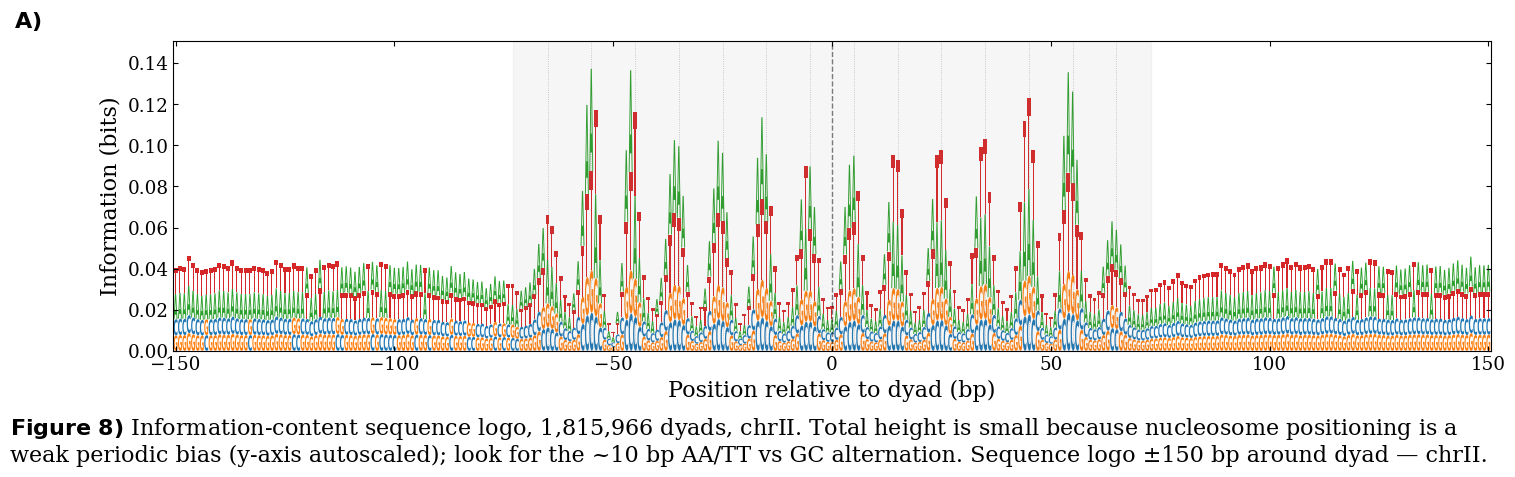

In [11]:
# ── Logo drawing helper (matplotlib TextPath — no logomaker dependency) ──────
from matplotlib.textpath import TextPath
from matplotlib.patches import PathPatch
from matplotlib.font_manager import FontProperties
from matplotlib.transforms import Affine2D

LETTER_COLORS = {'A': '#2ca02c', 'C': '#1f77b4', 'G': '#ff7f0e', 'T': '#d62728'}
_LOGO_FONT = FontProperties(family='DejaVu Sans', weight='bold')

def _letter_patch(letter, x, y0, width, height, color):
    """A PathPatch of `letter` stretched to fill (width, height) with lower-left at (x, y0)."""
    tp = TextPath((0, 0), letter, size=1, prop=_LOGO_FONT)
    bb = tp.get_extents()
    trans = (Affine2D()
             .translate(-bb.x0, -bb.y0)
             .scale(width / bb.width, height / bb.height)
             .translate(x, y0))
    return PathPatch(trans.transform_path(tp), facecolor=color, edgecolor='none')

def draw_logo(ax, letters, heights, positions, width=0.9, colors=LETTER_COLORS):
    """Stack `letters` (rows of `heights`, shape (n_letters, n_pos)) at each position, tallest on top."""
    for j, xpos in enumerate(positions):
        y = 0.0
        for k in np.argsort(heights[:, j]):        # smallest first -> largest ends on top
            h = heights[k, j]
            if h <= 1e-9:
                continue
            ax.add_patch(_letter_patch(letters[k], xpos - width / 2, y, width, h, colors[letters[k]]))
            y += h

# ── Sequence logo (information content) around the dyad ──────────────────────
logo_half = window_half             # ± bp shown in the logo (readable window)
center    = window_half              # dyad index inside enc_w / cov_w
sl        = slice(center - logo_half, center + logo_half + 1)
logo_pos  = np.arange(-logo_half, logo_half + 1)
n_logo    = 2 * logo_half + 1
BATCH     = 10_000

base_counts = np.zeros((4, n_logo), dtype=np.float64)
cov_total   = np.zeros(n_logo,      dtype=np.float64)
for s0 in range(0, len(all_dyad_records), BATCH):
    batch = all_dyad_records[s0:s0 + BATCH]
    enc = np.stack([r[3] for r in batch])[:, sl]
    cov = np.stack([r[4] for r in batch])[:, sl]
    base = enc % 4
    for b in range(4):
        base_counts[b] += ((base == b) & cov).sum(axis=0)
    cov_total += cov.sum(axis=0)

freq = base_counts / np.clip(cov_total, 1, None)          # (4, n) column-normalised frequencies
with np.errstate(divide='ignore', invalid='ignore'):
    H = -np.nansum(np.where(freq > 0, freq * np.log2(freq), 0.0), axis=0)
info        = 2.0 - H                                      # information content in bits (max 2)
seq_heights = freq * info                                  # per-letter contribution

plot.new(fig_size=FIG_SIZE)
ax = plt.gca()
draw_logo(ax, ['A', 'C', 'G', 'T'], seq_heights, logo_pos)
for c in shl_contacts:
    if abs(c) <= logo_half:
        ax.axvline(c, color='grey', lw=0.6, ls=':', alpha=0.5, zorder=0)
ax.axvline(0, color='k', lw=1, ls='--', alpha=0.5)
ax.axvspan(-core_half, core_half, alpha=0.07, color='grey', label=f'Core ±{core_half} bp')
ax.set_xlim(-logo_half - 0.5, logo_half + 0.5)
ax.set_ylim(0, max(info.max() * 1.1, 1e-3))
ax.set_xlabel("Position relative to dyad (bp)")
ax.set_ylabel("Information (bits)")
ax.set_title(f"Sequence logo ±{logo_half} bp around dyad — {chrom}")

plot.caption(
    f"Information-content sequence logo, {len(all_dyad_records):,} dyads, {chrom}. "
    "Total height is small because nucleosome positioning is a weak periodic bias "
    "(y-axis autoscaled); look for the ~10 bp AA/TT vs GC alternation."
)


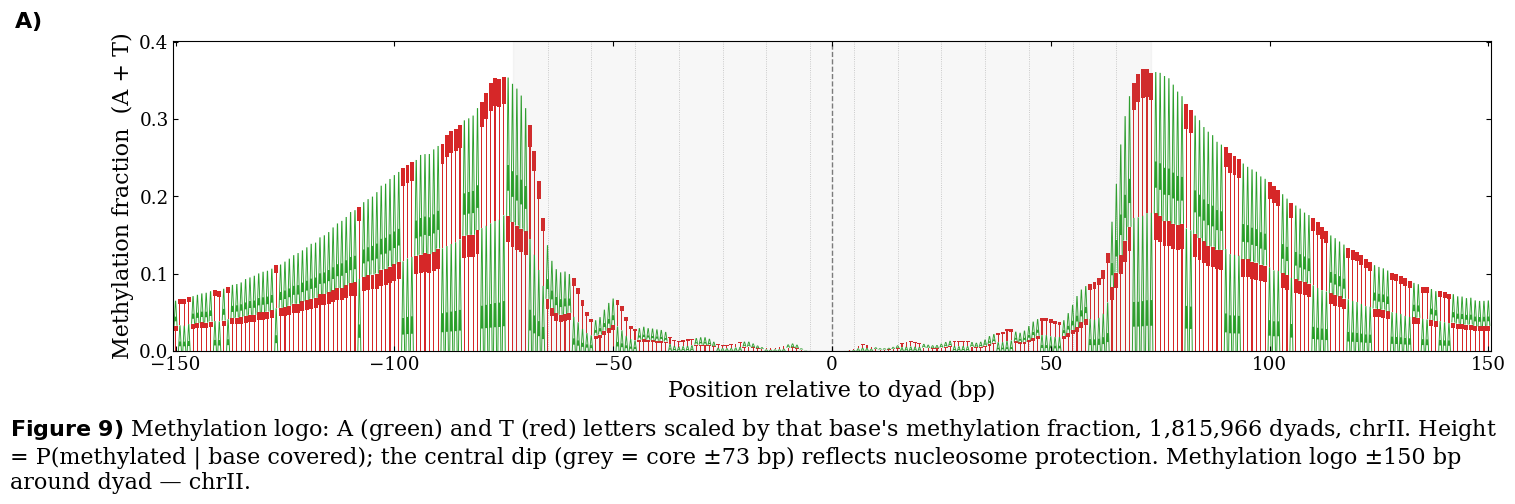

In [12]:
# ── Methylation logo: A/T letter heights = per-base methylation fraction ─────
# enc encoding: A=0/a=4, T=3/t=7  ->  methylated A == 4, methylated T == 7
methA = np.zeros(n_logo); atA = np.zeros(n_logo)
methT = np.zeros(n_logo); atT = np.zeros(n_logo)
for s0 in range(0, len(all_dyad_records), BATCH):
    batch = all_dyad_records[s0:s0 + BATCH]
    enc = np.stack([r[3] for r in batch])[:, sl]
    cov = np.stack([r[4] for r in batch])[:, sl]
    base = enc % 4
    isA = (base == 0) & cov
    isT = (base == 3) & cov
    methA += ((enc == 4) & isA).sum(axis=0)
    atA   += isA.sum(axis=0)
    methT += ((enc == 7) & isT).sum(axis=0)
    atT   += isT.sum(axis=0)

frac_A = methA / np.clip(atA, 1, None)                     # P(methylated | A covered)
frac_T = methT / np.clip(atT, 1, None)                     # P(methylated | T covered)
# rows A,C,G,T — only A and T carry height
meth_heights = np.vstack([frac_A, np.zeros(n_logo), np.zeros(n_logo), frac_T])

plot.new(fig_size=FIG_SIZE)
ax = plt.gca()
draw_logo(ax, ['A', 'C', 'G', 'T'], meth_heights, logo_pos)
for c in shl_contacts:
    if abs(c) <= logo_half:
        ax.axvline(c, color='grey', lw=0.6, ls=':', alpha=0.5, zorder=0)
ax.axvline(0, color='k', lw=1, ls='--', alpha=0.5)
ax.axvspan(-core_half, core_half, alpha=0.06, color='grey')
ax.set_xlim(-logo_half - 0.5, logo_half + 0.5)
ax.set_ylim(0, (frac_A + frac_T).max() * 1.1)
ax.set_xlabel("Position relative to dyad (bp)")
ax.set_ylabel("Methylation fraction  (A + T)")
ax.set_title(f"Methylation logo ±{logo_half} bp around dyad — {chrom}")
plot.caption(
    f"Methylation logo: A (green) and T (red) letters scaled by that base's methylation "
    f"fraction, {len(all_dyad_records):,} dyads, {chrom}. Height = P(methylated | base covered); "
    "the central dip (grey = core ±%d bp) reflects nucleosome protection." % core_half
)


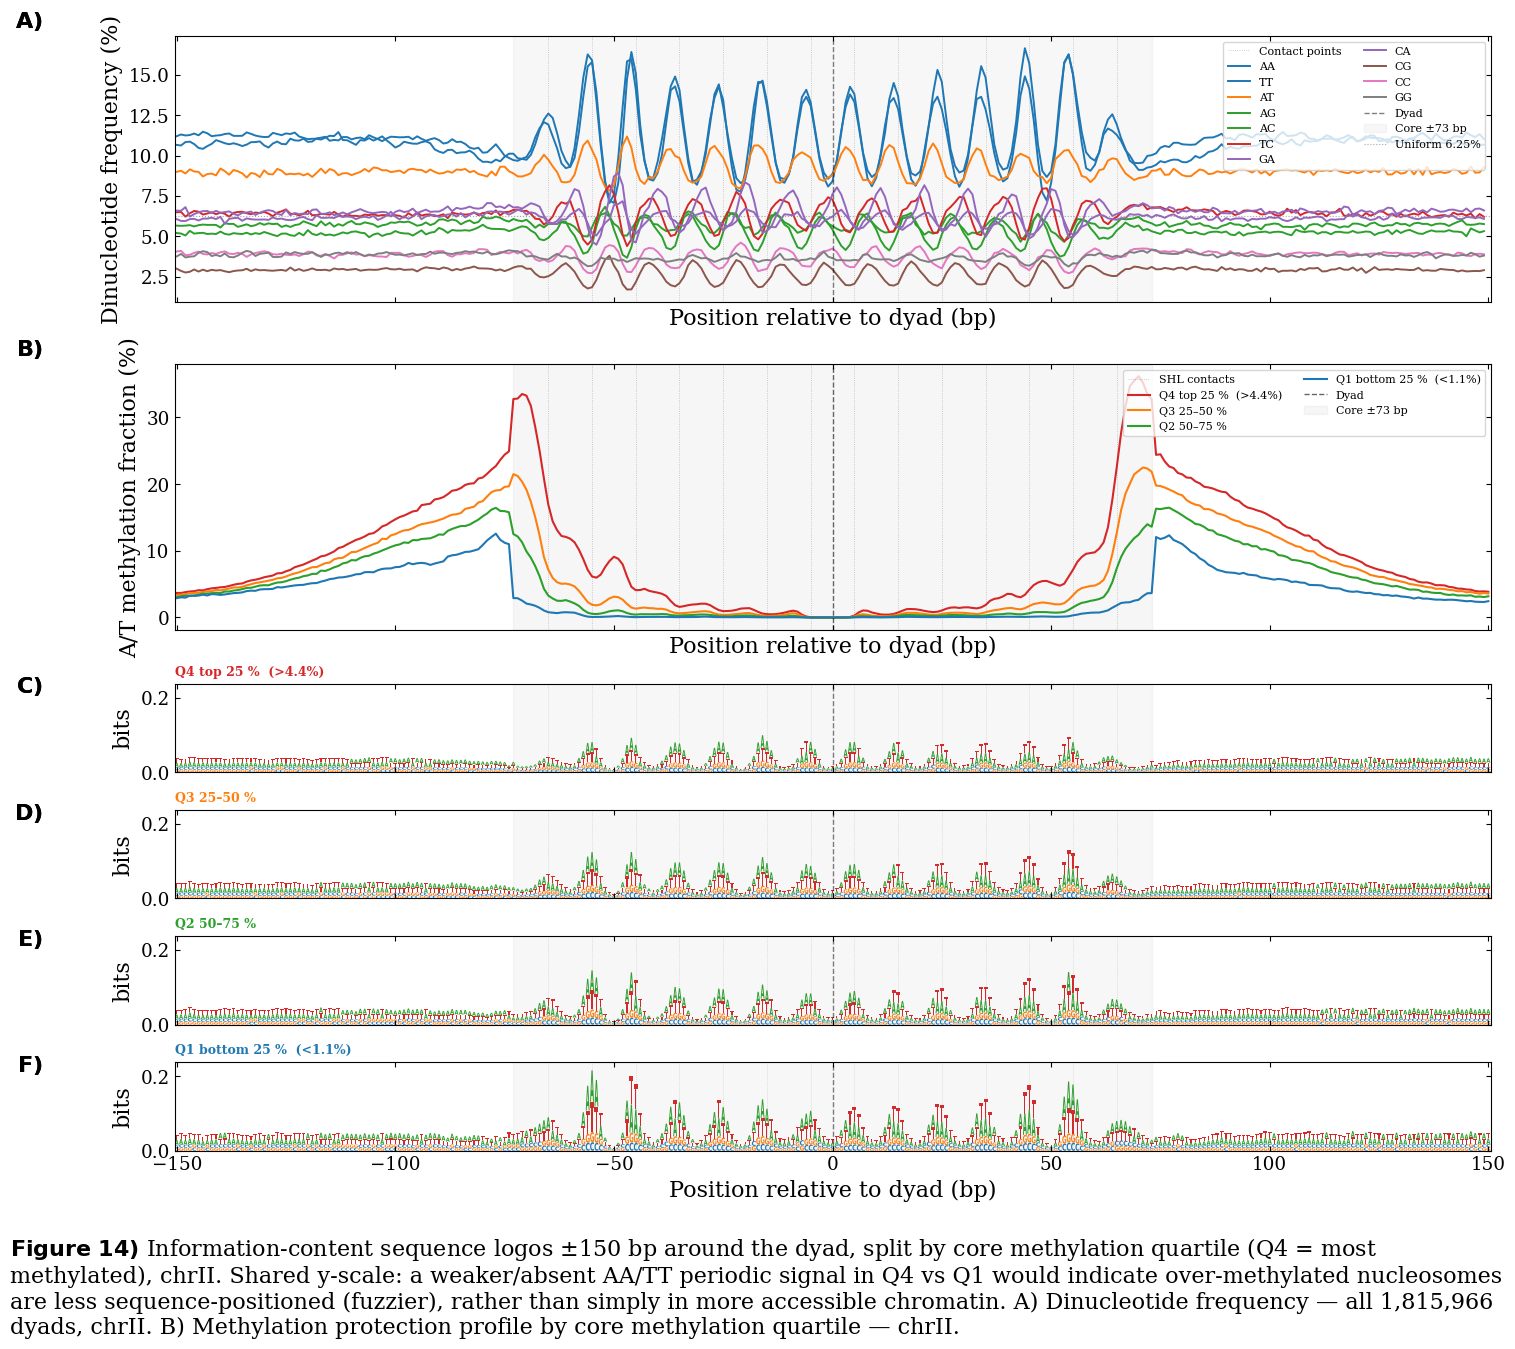

In [17]:
# ── Sequence logo comparison across core-methylation quartiles ───────────────
# One information-content sequence logo per quartile (Q4 top 25 % … Q1 bottom 25 %)
# to compare the DNA sequence dependence of over- vs under-methylated nucleosomes.
# Panels share a y-scale so the strength of the AA/TT positioning signal is comparable.

def seq_logo_heights(records, half, center):
    """Information-content logo matrix (4, 2*half+1) for a list of dyad records."""
    sl = slice(center - half, center + half + 1)
    n  = 2 * half + 1
    base_counts = np.zeros((4, n)); cov_total = np.zeros(n)
    BATCH = 10_000
    for s0 in range(0, len(records), BATCH):
        b = records[s0:s0 + BATCH]
        enc = np.stack([r[3] for r in b])[:, sl]
        cov = np.stack([r[4] for r in b])[:, sl]
        base = enc % 4
        for k in range(4):
            base_counts[k] += ((base == k) & cov).sum(axis=0)
        cov_total += cov.sum(axis=0)
    freq = base_counts / np.clip(cov_total, 1, None)
    with np.errstate(divide='ignore', invalid='ignore'):
        H = -np.nansum(np.where(freq > 0, freq * np.log2(freq), 0.0), axis=0)
    info = 2.0 - H
    return freq * info, info

logo_half = window_half             # ± bp per panel (smaller = more readable)
center    = window_half             # dyad index inside enc_w
q_logo_pos = np.arange(-logo_half, logo_half + 1)

# Per-quartile logos (quartile_groups & q_colors come from the stratified cell)
quartile_logos, ymax = {}, 0.0
for label, (lo, hi) in quartile_groups.items():
    h, info = seq_logo_heights(all_dyad_records[lo:hi], logo_half, center)
    quartile_logos[label] = h
    ymax = max(ymax, info.max())

plot.new(fig_size=(FIG_SIZE[0], 12), nrows=6, sharex=True, height_ratios=[3, 3, 1, 1, 1, 1])
axes = plot.axes

for i, pos in enumerate(shl_contacts):
    axes[0].axvline(pos, color='grey', lw=0.6, ls=':', alpha=0.5,
               label='Contact points' if i == 0 else None, zorder=0)
for (label, freq), color in zip(to_plot_all.items(), colors):
    axes[0].plot(di_positions, freq * 100, lw=1.4, label=label, color=color)
axes[0].axvline(0, color='k', lw=1, ls='--', alpha=0.5, label='Dyad')
axes[0].axvspan(-core_half, core_half, alpha=0.06, color='grey', label=f'Core ±{core_half} bp')
axes[0].axhline(100 / 16, color='grey', lw=0.8, ls=':', alpha=0.7, label='Uniform 6.25%')
axes[0].set_xlabel("Position relative to dyad (bp)")
axes[0].set_ylabel("Dinucleotide frequency (%)")
axes[0].set_xlim(-window_half, window_half)
axes[0].set_title(f"Dinucleotide frequency — all {len(all_dyad_records):,} dyads, {chrom}")
axes[0].legend(fontsize=8, ncol=2, loc='upper right')

pos = np.arange(-window_half, window_half + 1)
for i, c in enumerate(shl_contacts):
    axes[1].axvline(c, color='grey', lw=0.6, ls=':', alpha=0.5,
               label='SHL contacts' if i == 0 else None, zorder=0)
for (label, (lo, hi)), color in zip(quartile_groups.items(), q_colors):
    prof = meth_profile_for_records(all_dyad_records[lo:hi])
    quartile_profiles[label] = prof
    axes[1].plot(pos, prof * 100, lw=1.5, color=color, label=label)
axes[1].axvline(0, color='k', lw=1, ls='--', alpha=0.6, label='Dyad')
axes[1].axvspan(-core_half, core_half, alpha=0.07, color='grey', label=f'Core ±{core_half} bp')
axes[1].set_xlabel("Position relative to dyad (bp)")
axes[1].set_ylabel("A/T methylation fraction (%)")
axes[1].set_xlim(-window_half, window_half)
axes[1].legend(fontsize=8, ncol=2, loc='upper right')
axes[1].set_title(f"Methylation protection profile by core methylation quartile — {chrom}")

for ax, (label, h), color in zip(axes[2:], quartile_logos.items(), q_colors):
    draw_logo(ax, ['A', 'C', 'G', 'T'], h, q_logo_pos)
    for c in shl_contacts:
        if abs(c) <= logo_half:
            ax.axvline(c, color='grey', lw=0.5, ls=':', alpha=0.4, zorder=0)
    ax.axvspan(-core_half, core_half, alpha=0.06, color='grey')
    ax.axvline(0, color='k', lw=1, ls='--', alpha=0.5)
    ax.set_ylim(0, ymax * 1.1)       # shared y-scale -> panels directly comparable
    ax.set_ylabel("bits")
    ax.set_title(label, fontsize=9, loc='left', color=color, fontweight='bold')

plt.suptitle(f"Sequence logo by core-methylation quartile — {chrom}", fontsize=11, y=0.995)
axes[-1].set_xlim(-logo_half - 0.5, logo_half + 0.5)
axes[-1].set_xlabel("Position relative to dyad (bp)")
plot.caption(
    f"Information-content sequence logos ±{logo_half} bp around the dyad, split by core "
    f"methylation quartile (Q4 = most methylated), {chrom}. Shared y-scale: a weaker/absent "
    "AA/TT periodic signal in Q4 vs Q1 would indicate over-methylated nucleosomes are less "
    "sequence-positioned (fuzzier), rather than simply in more accessible chromatin."
)
